# 🃏 Analyse statistique de parties de poker Winamax

Mathis KACER, Ivann MINOC

Ce notebook présente une analyse des historiques de parties **Expresso Nitro** et **Expresso** issus de la plateforme Winamax. Ce type de partie a tendance à être rapide. Pour simplifier nos analyses, nous nous sommes limités au jeu avant le flop, qui repose uniquement sur les cartes qu'on a en main.

**Données** : fichiers d'historiques `.txt` parsés et chargés depuis un stockage S3 (SSPCloud)  
**Objectifs** :
- Décrire les statistiques de jeu globales
- Analyser les comportements selon la position et le stack
- Visualiser les ranges de mains jouées

---

## 0. Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.creation_bdd_mains   import parse_file, parse_folder
from data.creation_bdd_tournois import parse_folder_resume
from data.tri_dossier           import trier_fichiers
from data.chargement_txt        import load_data_from_s3
from src.ranges                 import range, affichage_range
from src.decision_par_position  import analyse_stack_bb
from src.winrate                import winrate_par_position

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Chargement des données

Les données brutes sont constituées de fichiers texte (.txt) exportés depuis la plateforme Winamax, collectés à partir des historiques de jeu de plusieurs joueurs — les membres du groupe ainsi que leurs proches. Chaque fichier correspond à une session de jeu. Ces fichiers suivent un format semi-structuré propre à Winamax, où chaque main est délimitée par un en-tête standardisé et décrit séquentiellement les actions de chaque joueur à chaque rue (préflop, flop, turn, river). Winamax génère également, pour chaque session, un fichier résumé (_summary.txt) qui agrège les informations globales du tournoi : classement final, gains et pertes de chaque participant.
Afin de rendre ces données exploitables, deux parsers Python ont été développés, reposant sur des expressions régulières. Le premier traite les fichiers de mains détaillés et extrait, pour chaque main jouée, les informations pertinentes : identifiants de tournoi, niveau de blindes, position du joueur, cartes distribuées, actions préflop et postflop, résultat financier. Le joueur d'intérêt (le « héros ») est détecté automatiquement via la ligne Dealt to, ce qui permet au parser de traiter indifféremment les historiques de n'importe quel joueur sans configuration manuelle. Le second parser traite les fichiers résumés et en extrait les résultats globaux de chaque tournoi.
Ces deux parsers produisent chacun un DataFrame pandas consolidé :

tableau_mains — une ligne par main jouée, avec toutes les features comportementales et financières associées (position, stack en BB, fold préflop, all-in préflop, cartes, bénéfice net en BB, etc.)
tableau_tournois — une ligne par tournoi disputé, avec le résultat global (gain ou perte, classement final, buy-in)

Ces deux bases de données constituent le socle sur lequel reposent toutes les analyses statistiques présentées dans ce notebook.

In [2]:
PROJECT_DIR = os.getcwd()

load_data_from_s3(
    project_dir=PROJECT_DIR,
    s3_path='mathiskacer2/diffusion/projet_poker/history.zip'
)

trier_fichiers('data/historique/history/', 'data/mains/', 'data/resumes/')

['__MACOSX', 'history']


In [3]:
tableau_mains    = parse_folder('data/mains/')
tableau_tournois = parse_folder_resume('data/resumes/')

print(f'Mains     : {len(tableau_mains):>6} lignes  x {tableau_mains.shape[1]} colonnes')
print(f'Tournois  : {len(tableau_tournois):>6} lignes  x {tableau_tournois.shape[1]} colonnes')

Mains     :  18297 lignes  x 37 colonnes
Tournois  :   1925 lignes  x 8 colonnes


## 2. Aperçu du jeu de données

In [4]:
tableau_mains.head(5)

,tournament,buy_in_price,buy_in_rake,buy_in_total,level,hand_id,id_table,numero_main,sequence,sb,bb,datetime,id_tournoi,hero,hero_seat,stack_start,total_players,position,stack_bb,cartes,main,fold_preflop,allin_preflop,flop,turn,river,saw_flop,saw_turn,saw_river,went_to_showdown,won_at_showdown,total_pot,gain,gain bb,benefice net,benefice bb,source_file
0,Expresso,0.230,0.020,0.250,1,3959423895123001345-1-1743180858,3959423895123001345,1,1743180858,10,20,2025-03-28 16:54:18,921875214,MathisKcr,2,500,3,BTN,25.000,3d 6s,63o,True,False,None,None,None,False,False,False,False,False,520,0,0.000,0,0.000,20250328_Expresso(921875214)_real_holdem_no-li...
1,Expresso,0.230,0.020,0.250,1,3959423895123001345-2-1743180865,3959423895123001345,2,1743180865,10,20,2025-03-28 16:54:25,921875214,MathisKcr,2,500,3,BB,25.000,4d 8h,84o,False,False,Ts Qc 5d,None,None,True,False,False,False,False,100,0,0.000,-20,-1.000,20250328_Expresso(921875214)_real_holdem_no-li...
2,Expresso,0.230,0.020,0.250,1,3959423895123001345-3-1743180884,3959423895123001345,3,1743180884,10,20,2025-03-28 16:54:44,921875214,MathisKcr,2,480,3,SB,24.000,Tc 9h,T9o,True,False,None,None,None,False,False,False,False,False,202,0,0.000,-20,-1.000,20250328_Expresso(921875214)_real_holdem_no-li...
3,Expresso,0.230,0.020,0.250,1,3959423895123001345-4-1743180901,3959423895123001345,4,1743180901,10,20,2025-03-28 16:55:01,921875214,MathisKcr,2,460,3,BTN,23.000,Th As,ATo,False,False,None,None,None,False,False,False,False,False,70,70,3.500,30,1.500,20250328_Expresso(921875214)_real_holdem_no-li...
4,Expresso,0.230,0.020,0.250,1,3959423895123001345-5-1743180915,3959423895123001345,5,1743180915,10,20,2025-03-28 16:55:15,921875214,MathisKcr,2,490,3,BB,24.500,9c Th,T9o,True,False,None,None,None,False,False,False,False,False,590,0,0.000,-20,-1.000,20250328_Expresso(921875214)_real_holdem_no-li...


In [ ]:
# Types et valeurs manquantes
tableau_mains.info()

## 3. Statistiques descriptives globales

Quelques indicateurs clés sur l'ensemble des mains jouées.

In [5]:
df = tableau_mains

stats = {
    'Nombre de mains'         : len(df),
    'Nombre de joueurs uniques': df['hero'].nunique(),
    'Formats de tournoi'       : ', '.join(df['tournament'].unique()),
    'Fold préflop (%)'         : df['fold_preflop'].mean() * 100,
    'All-in préflop (%)'       : df['allin_preflop'].mean() * 100,
    'Vu le flop (%)'           : df['saw_flop'].mean() * 100,
    'Showdown (%)'             : df['went_to_showdown'].mean() * 100,
    'Gagné au showdown (%)'    : df.loc[df['went_to_showdown'], 'won_at_showdown'].mean() * 100,
}

for k, v in stats.items():
    if isinstance(v, float):
        print(f'{k:<30} {v:.2f}')
    else:
        print(f'{k:<30} {v}')

Nombre de mains                18297
Nombre de joueurs uniques      1
Formats de tournoi             Expresso, Expresso Nitro, Expresso Nitro Freeroll
Fold préflop (%)               30.94
All-in préflop (%)             27.02
Vu le flop (%)                 54.52
Showdown (%)                   35.55
Gagné au showdown (%)          51.28


## 4. Ranges de mains

Visualisation des ranges pour chaque joueur.

`metric` peut être :
- `'mean'` — espérance de gain par main
- `'var'`  — volatilité par main
- `'freq'` — fréquence d'ouverture

`hero` est le pseudo Winamax du joueur à analyser.

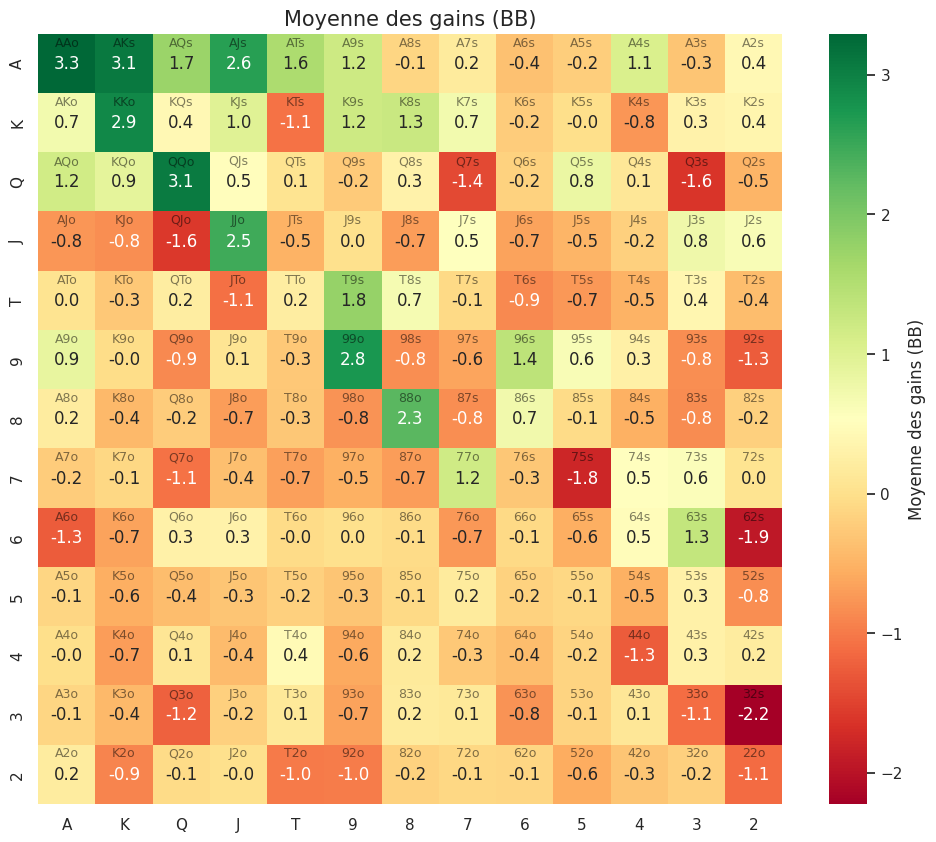

In [6]:
affichage_range(tableau_mains, metric='mean', hero='MathisKcr')

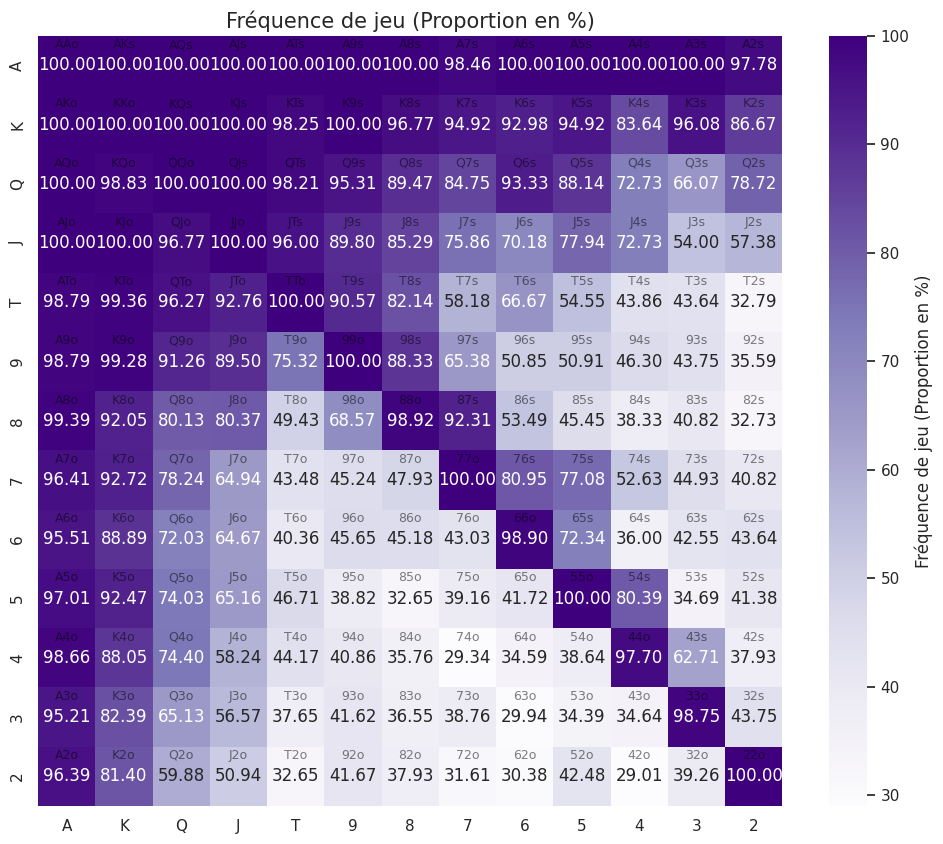

In [7]:
affichage_range(tableau_mains, metric='freq', hero='MathisKcr')

## 5. Analyse décisionnelle selon le stack

On segmente les mains par tranche de **stack en nombre de big blindes** et on observe :
- le taux de **fold préflop** — diminue quand le stack est court (mode push/fold)
- le taux d'**all-in préflop** — augmente très nettement quand le stack est court

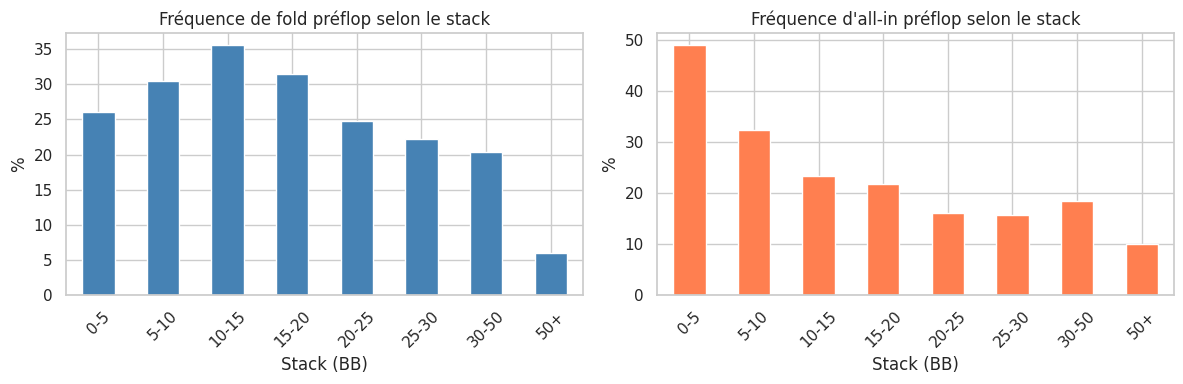

,nb_mains,fold_pf_pct,allin_pf_pct
stack_bb_range,,,
0-5,1940,0.261,0.489
5-10,4315,0.305,0.324
10-15,6747,0.355,0.234
15-20,2756,0.314,0.217
20-25,1392,0.247,0.162
25-30,528,0.222,0.157
30-50,569,0.204,0.185
50+,50,0.060,0.100


In [8]:
stats_stack = analyse_stack_bb(tableau_mains)
stats_stack

**Lecture** : En dessous de 10 BB, la fréquence d'all-in préflop dépasse 30 %, reflétant une stratégie all-in/fold adaptée aux types de parties étudiées (Expresso)

## 6. Winrate par position

Comparaison du gain moyen (en BB) selon la position à la table : **BTN**, **SB**, **BB**.

En théorie, le BTN (bouton) est la position la plus avantageuse car le joueur agit en dernier postflop.

          nb_mains  winrate_bb  net_bb_total
position                                    
BB            7543      -0.252     -1897.710
BTN           7532      -0.168     -1263.720
SB            3222      -0.280      -903.040


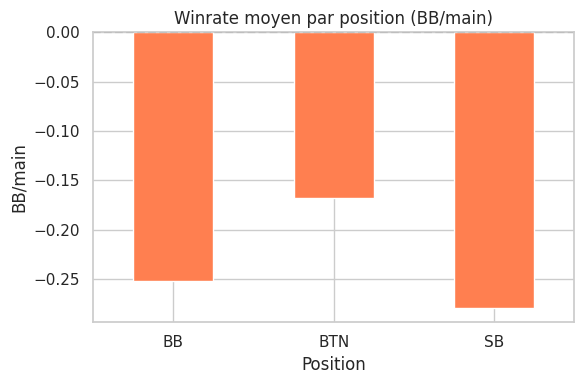

In [9]:
stats_pos = winrate_par_position(tableau_mains)
stats_pos

**Lecture** : Nos données montrent qu'on a tendance perdre dans toutes les positions. Toutefois, on voit qu'on perd moin au lorsqu'on est au bouton (BTN), ce qui suit les théories du poker.